## Домашнее задание 22

### Задача 1

Ivy Cube для тех, кто не доделал (или кто вайбкодил. Уберите это и сделайте сами)

In [ ]:
# YOUR CODE HERE



### Задача 2

На занятии был рассмотрен граф параллелепипеда Рубика $1 \times 2 \times 3$. Было выяснено, что если повороты правой и верхней половины - это $a$ и $b$, то верно, что $a^2 = b^2 = (ab)^3 = e$ (единичному повороту, пустой строке).

Реализуйте сокращение строк с поворотами. На вход поступает строка из символов $a$ и $b$, нужно вернуть строку минимальной длины, получившуюся из входной применением правил сокращения. Напишите тесты для своей программы. Сгенерируйте случайные строки длины 100 и постройте распределение длин строк, в которые они превращаются. Как это распределение соотносится с диаметром графа головоломки?

In [ ]:
# YOUR CODE HERE



### Задача 3: обход препятствий.

Сведем задачу обхода препятствий к поиску кратчайшего пути в графе.

Ниже дано несколько заготовок кода.

Первая из них позволяет определить, пересекается ли некоторый отрезок с препятствиями.

Вторая содержит представление препятствий в виде набора вершин вокруг них и рисование только тех ребер, которые не пересекаются с препятствиями. Там нужно дописать одну небольшую вещь, и все заработает.

В третьей заготовке нужно дописать ровно то же самое, что и во второй, и тогда перестроение графа будет происходить по мере движения препятствий.

Для выполнения этой задачи рекомендуется использовать локальный юпитер ноутбук, а не колаб из-за необходимости визуализации в отдельном окне.

Подзадачи:
- выполните подготовительные шаги
- САМОСТОЯТЕЛЬНО реализуйте алгоритм Дейкстры
- примените алгоритм Дейкстры к задаче поиска кратчайшего пути из старта в финиш
- визуализируйте найденный кратчайший путь

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

mask = np.zeros((600, 900), np.uint8)

def intersects(obstacle_mask, n1, n2):
    edge_cand = np.zeros_like(obstacle_mask)
    cv2.line(edge_cand, n1, n2, (255), 1)
    
    intersection = cv2.bitwise_and(obstacle_mask, edge_cand)

    # plt.imshow(obstacle_mask)
    # plt.show()
    # plt.imshow(edge_cand)
    # plt.show()
    # plt.imshow(intersection)
    # plt.show()
    
    return np.sum(intersection) != 0

n1 = (100, 200)
n2 = (400, 50)

print(intersects(mask, n1, n2))

False


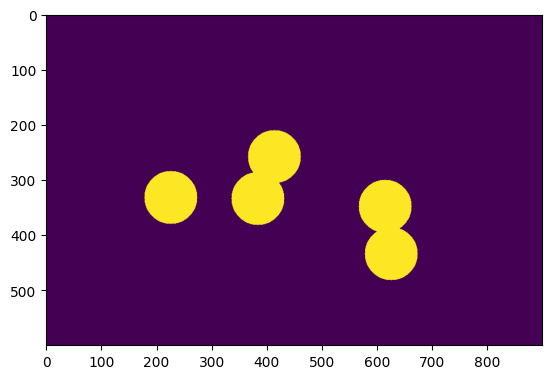

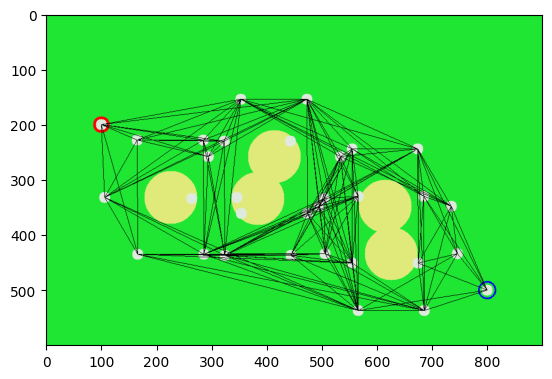

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

mask = np.zeros((600, 900), np.uint8)
field = np.zeros((600, 900, 3), np.uint8)
field[:, :, 0] = 30
field[:, :, 1] = 230
field[:, :, 2] = 50

rx, ry, tx, ty = 100, 200, 800, 500

cv2.circle(field, (rx, ry), 15, (255, 0, 0), -1)
cv2.circle(field, (tx, ty), 15, (0, 0, 255), 2)

approx_points_num = 6
obstacle_r = 120
obstacles = []

for i in range(5):
    x = np.random.randint(500) + 200
    y = np.random.randint(300) + 200
    
    #cv2.line(canvas, (x, y), (x + w, y + h), (255), 80)
    cv2.circle(mask, (x, y), int(obstacle_r * 0.4), (255), -1)
    cv2.circle(field, (x, y), int(obstacle_r * 0.4), (223, 234, 123), -1)

    obstacles.append((x, y))

nodes = []
edges = []

nodes.append((rx, ry))
nodes.append((tx, ty))

for obst in obstacles:
    for i in range(approx_points_num):
        angle = 2 * np.pi / approx_points_num * i
        obstx = int(obst[0] + obstacle_r * np.cos(angle))
        obsty = int(obst[1] + obstacle_r * np.sin(angle))
        nodes.append((obstx, obsty))

for i in range(len(nodes)):
    for j in range(i + 1, len(nodes)):
        if (# YOUR CODE HERE):
            edges.append((i, j))

for n in nodes:
    cv2.circle(field, (int(n[0]), int(n[1])), 10, (223, 234, 223), -1)

for e in edges:
    cv2.line(field, nodes[e[0]], nodes[e[1]], (3, 4, 3), 1)

plt.imshow(mask)
plt.show()

plt.imshow(field)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

def generate_graph(field, mask, obstacles):
    nodes = []
    edges = []

    nodes.append((rx, ry))
    nodes.append((tx, ty))

    for obst in obstacles:
        for i in range(approx_points_num):
            angle = 2 * np.pi / approx_points_num * i
            obstx = int(obst[0] + obstacle_r * np.cos(angle))
            obsty = int(obst[1] + obstacle_r * np.sin(angle))
            nodes.append((obstx, obsty))

    for i in range(len(nodes)):
        for j in range(i + 1, len(nodes)):
            if (# YOUR CODE HERE):
                edges.append((i, j))

    for n in nodes:
        cv2.circle(field, (int(n[0]), int(n[1])), 10, (223, 234, 223), -1)

    for e in edges:
        cv2.line(field, nodes[e[0]], nodes[e[1]], (3, 4, 3), 1)

mask = np.zeros((600, 900), np.uint8)
field = np.zeros((600, 900, 3), np.uint8)

rx, ry, tx, ty = 100, 200, 800, 500

approx_points_num = 6
obstacle_r = 120
obstacles_ = []
obst_osc_r = 50

obst_num = 5

for i in range(obst_num):
    x = np.random.randint(500) + 200
    y = np.random.randint(300) + 200
    
    #cv2.line(canvas, (x, y), (x + w, y + h), (255), 80)
    cv2.circle(mask, (x, y), int(obstacle_r * 0.9), (255), -1)
    cv2.circle(field, (x, y), int(obstacle_r * 0.9), (223, 234, 123), -1)

    obstacles_.append((x, y))

k = 0

while (True):
    field[:, :, 0] = 30
    field[:, :, 1] = 230
    field[:, :, 2] = 50
    mask[:, :] = 0

    cv2.circle(field, (rx, ry), 15, (255, 0, 0), -1)
    cv2.circle(field, (tx, ty), 15, (0, 0, 255), 2)
    
    obstacles = []
    
    for i in range(obst_num):
        x = obstacles_[i][0]
        y = obstacles_[i][1]
        
        if (i % 2 == 0):
            x += int(obst_osc_r * np.sin(k / 10.0))

        else:
            y += int(obst_osc_r * np.sin(k / 12.0))
        
        #cv2.line(canvas, (x, y), (x + w, y + h), (255), 80)
        cv2.circle(mask, (x, y), int(obstacle_r * 0.4), (255), -1)
        cv2.circle(field, (x, y), int(obstacle_r * 0.4), (223, 234, 123), -1)

        obstacles.append((x, y))
    
    generate_graph(field, mask, obstacles)
    
    cv2.imshow("field", field)
    
    key = cv2.waitKey(50)
    
    if (key == ord('q')):
        break
    
    k += 1
    print(k)

cv2.destroyAllWindows()
cv2.waitKey(50)

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277


-1

In [ ]:
# YOUR CODE HERE



### Задача 4

Реализуйте алгоритм Беллмана-Форда и визуализацию всех его шагов. Попробуйте запустить его на графе с отрицательным циклом

In [ ]:
# YOUR CODE HERE



### Задача 5*: вот это поворот.

Реализуйте обход препятствий с учетом конечной скорости поворота робота на плоскости.

Робот может поворачивать с минимальным радиусом кривизны в 1 метр. Дискретизуйте пространство, разделив его на квадраты со стороной 25 см, и добавьте третью размерность, соответствующую углу. Реализуйте нахождение кратчайших путей, если вес имеет и линейное перемещение, и поворот. Добавьте препятствия (это соответствует удалению некоторых вершин). Найдите конфигурацию препятствий, при которой от соотношений весов перемещения и поворота меняется кратчайший путь.